# Exploring segmenting processing tanks in hyperspectral imagery

What we want to know: 
* Can we use known instances of the cobalt circuit on a processing facility to find other instances?
* Can we use known instances of the tank holding cobalt hydroxide on a processing facility to find other instances?

In [1]:
### Path adjustment so internal functions can be imported

import sys
import os # for file handling

# Add the parent directory to the system path
parent_dir = os.path.abspath(os.path.join(sys.path[0], ".."))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

print("Parent directory added to sys.path:", parent_dir)    

Parent directory added to sys.path: /Users/rmanzuk/Princeton Dropbox/Ryan Manzuk/code/hyperspectral_u_sensing


In [3]:
### Package imports
import geopandas as gpd # for handling geospatial data
import h5py # the hyperspectral data is in hdf5 format
from rasterio.features import rasterize # to make masks from shapefiles
import matplotlib.pyplot as plt # gotta plot
import numpy as np # for numerical operations
from shapely import box 
from sklearn.decomposition import PCA
import rasterio as rio # for reading/writing geospatial raster data

In [4]:
### Function imports

import hyperspectral_u_sensing.processing.tanager_file_handling as tanager_file_handling
import hyperspectral_u_sensing.processing.hyperspectral_corrections as hyperspectral_corrections

In [ ]:
### Load in the hyperspectral data

# set a base path
base_path = '/Users/rmanzuk/Princeton Dropbox/Ryan Manzuk/drc_hyperspectral'

# sub path for the kolwezi hyperspectral data
im_subpath = 'tanager_ims_drc/commus-order_tan-ortho-radiance_20250625'
im_path = os.path.join(base_path, im_subpath)

# search through the subdirectories for hdf5 file and the metadata.json file
scene_path, metadata_path = tanager_file_handling.find_subpaths(im_path)

# load the hyperspectral data
scene_file = h5py.File(scene_path, 'r')
scene_key = tanager_file_handling.scene_key(True)
rad_array, rad_attrs = tanager_file_handling.load_radiance(scene_file, scene_key)

# some custom functions to get geo-referencing info from the metadata
metadata = tanager_file_handling.h5_metadata(scene_file)
georef_info = tanager_file_handling.extract_georef_info(metadata)
ref_transform = tanager_file_handling.build_affine_transform(georef_info)
ref_crs = tanager_file_handling.build_crs(georef_info)
ref_shape = (georef_info['YDim'], georef_info['XDim'])

# print the shape of the radiance array as a check
print("Radiance array shape:", rad_array.shape)

Radiance array shape: (426, 658, 775)
Radiance array attributes: {'Unit': 'W/(m^2 sr um)', '_FillValue': np.float32(-9999.0), 'applied_radiometric_coefficients': array([0.24117877, 0.19664247, 0.12794702, 0.10599381, 0.0785861 ,
       0.06810818, 0.05935678, 0.04755091, 0.04190101, 0.03722739,
       0.03394626, 0.0303052 , 0.02826379, 0.02598685, 0.02387025,
       0.02336355, 0.02251674, 0.02208806, 0.02204469, 0.02220925,
       0.02168082, 0.02049176, 0.01993347, 0.01987995, 0.01913034,
       0.01838925, 0.01796245, 0.01744622, 0.01674083, 0.01709536,
       0.01676122, 0.01611635, 0.01537274, 0.01469532, 0.0143942 ,
       0.01404121, 0.01360779, 0.01338364, 0.01328742, 0.01275896,
       0.01256888, 0.01229605, 0.01184709, 0.01151312, 0.01140921,
       0.01112384, 0.01085087, 0.01073875, 0.01054627, 0.01030221,
       0.0100322 , 0.01017956, 0.01043109, 0.01048737, 0.01056168,
       0.01062509, 0.01038046, 0.01180799, 0.01294908, 0.01158617,
       0.01024127, 0.01051945, 0.0

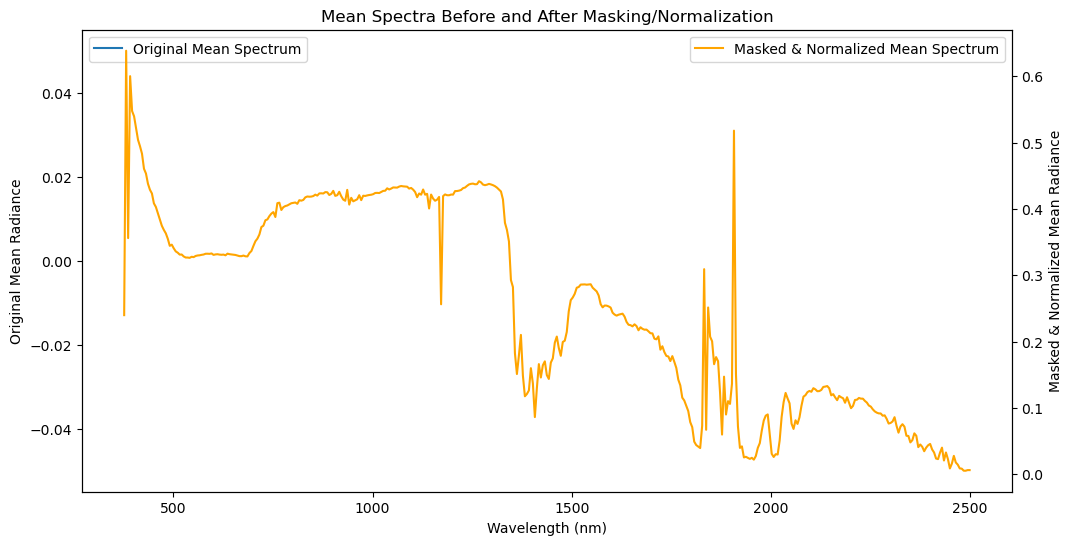

In [34]:
### make some adjustments to the radiance array to get rid of the bad bands (most atmospherically affected) a mask out no data values

# need the mean spectrum to feed into the band function
mean_spectrum = np.mean(rad_array, axis=(1,2))

# make the bad band mask and associated bits
#bad_mask = hyperspectral_corrections.tanager_bad_band_mask(rad_attrs['wavelengths'],
                          #spectrum=mean_spectrum,
                          #pad_nm=20)

#good_mask = ~bad_mask
#bad_indices = np.where(bad_mask)[0].tolist()
#rad_array_masked = rad_array[good_mask]
#wavelengths_masked = rad_attrs['wavelengths'][good_mask]

rad_array_masked = rad_array

# take care of the no data values
no_data_val = rad_attrs['_FillValue']
no_data_mask = np.any(rad_array_masked == no_data_val, axis=0)
rad_array_masked[:, no_data_mask] = np.nan

# use the function to max normalize each band
rad_array_masked = hyperspectral_corrections.band_max_norm(rad_array_masked)

# and make a new mean spectrum
normalized_mean_spectrum = np.nanmean(rad_array_masked, axis=(1,2))

# plot both mean spectra to check on a double y axis plot
plt.figure(figsize=(12, 6))
plt.plot(rad_attrs['wavelengths'], mean_spectrum, label='Original Mean Spectrum')
# double y axis plot
ax1 = plt.gca()
ax2 = ax1.twinx()
ax2.plot(rad_attrs['wavelengths'], normalized_mean_spectrum, color='orange', label='Masked & Normalized Mean Spectrum')
ax1.set_xlabel('Wavelength (nm)')
ax1.set_ylabel('Original Mean Radiance')
ax2.set_ylabel('Masked & Normalized Mean Radiance')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.title('Mean Spectra Before and After Masking/Normalization')
plt.show()

Explained variance ratio: [0.8222244  0.10616103 0.03494501 0.00813632 0.00492784]


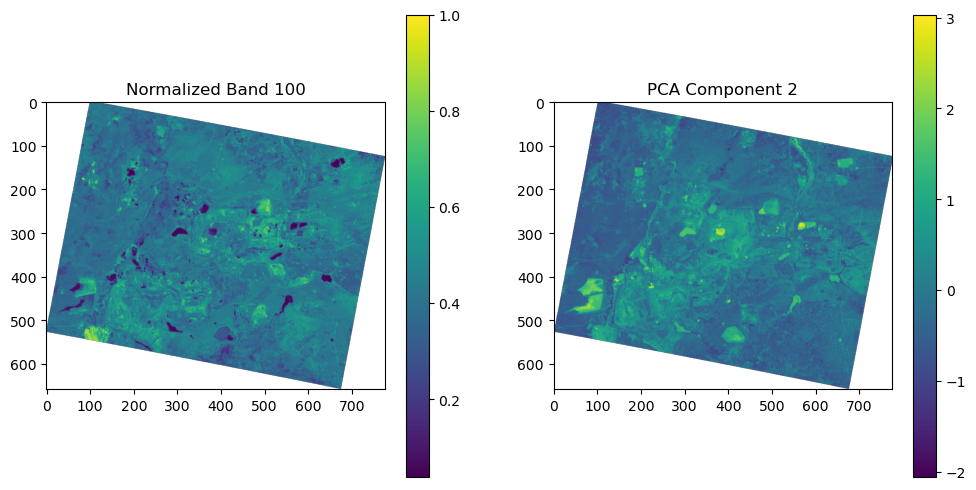

In [35]:
### Last bit of image prep, run a PCA on the normalized image, we'll use those components for to look through tank instances

# reshape the array so there is 1 column per band
rad_array_reshaped = rad_array_masked.reshape(-1, rad_array_masked.shape[-1]* rad_array_masked.shape[-2]).T

# remove rows with nans
rad_array_reshaped = rad_array_reshaped[~np.isnan(rad_array_reshaped).any(axis=1)]

n_components = 5
pca = PCA(n_components=n_components)
pca.fit(rad_array_reshaped)

# grab the spectra, we need these to reproject the data.
component_spectra = pca.components_

# need to make a new reshaped array to project the data into the PCA space
rad_array_reshaped = rad_array_masked.reshape(-1, rad_array_masked.shape[-1]* rad_array_masked.shape[-2]).T

# multiply the reshaped array by the component spectra to get the scores
rad_pc_scores = rad_array_reshaped @ component_spectra.T

# reshape back into an image
rad_pc_image = rad_pc_scores.T.reshape(n_components, rad_array_masked.shape[1], rad_array_masked.shape[2])

# as a check, print the percentage of variance explained by each component
print("Explained variance ratio:", pca.explained_variance_ratio_)

# and plot one of the bands from the normalized image and the 2nd PCA component
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(rad_array_masked[100], cmap='viridis')
plt.title('Normalized Band 100')
plt.colorbar()
plt.subplot(1, 2, 2)
plt.imshow(rad_pc_image[1], cmap='viridis')
plt.title('PCA Component 2')
plt.colorbar()
plt.show()

In [36]:
### we know where the cobalt decanters are one facility, locate those pixels in image space

# manually listing the center coordinates of the cobalt circuite tanks for now in lat, lon
cobalt_tank_coords = [[-10.6815301,25.3877978],
                      [-10.6817404,25.3875897],
                      [-10.6819506,25.3874138],
                      [-10.6821379,25.3872468],
                      [-10.6823279,25.3870533],
                      [-10.6825411,25.3868658]]

# convert to a geodataframe
cobalt_tank_gdf = gpd.GeoDataFrame(geometry=gpd.points_from_xy(
    [coord[1] for coord in cobalt_tank_coords],
    [coord[0] for coord in cobalt_tank_coords]),
    crs='EPSG:4326')

# reproject to the image CRS
cobalt_tank_gdf = cobalt_tank_gdf.to_crs(ref_crs)

# now for each poing, convert to image coordinates
cobalt_tank_pixels = []
for pt in cobalt_tank_gdf.geometry:
    x, y = pt.x, pt.y
    row, col = rio.transform.rowcol(ref_transform, x, y)   # important: row, col order
    cobalt_tank_pixels.append((int(row), int(col)))

print("Cobalt tank pixel coordinates (row, col):", cobalt_tank_pixels)


Cobalt tank pixel coordinates (row, col): [(235, 321), (236, 321), (237, 320), (238, 319), (238, 319), (239, 318)]


Extracting PCA values at pixel (row, col): (235, 321)
Extracting PCA values at pixel (row, col): (236, 321)
Extracting PCA values at pixel (row, col): (237, 320)
Extracting PCA values at pixel (row, col): (238, 319)
Extracting PCA values at pixel (row, col): (238, 319)
Extracting PCA values at pixel (row, col): (239, 318)


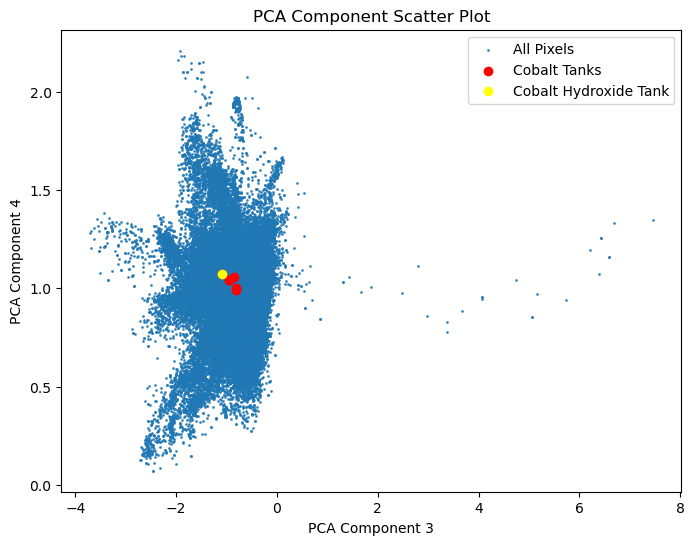

In [38]:
### extract the PCA values at the tank locations
cobalt_tank_pca_values = []
for (row, col) in cobalt_tank_pixels:
    print("Extracting PCA values at pixel (row, col):", (row, col))
    pca_values = rad_pc_image[:, row, col]
    cobalt_tank_pca_values.append(pca_values)

cobalt_tank_pca_values = np.array(cobalt_tank_pca_values)

# plot the pc values of the tanks vs the rest of the image
pcx = 2
pcy = 3

plt.figure(figsize=(8, 6))
plt.scatter(rad_pc_image[pcx].flatten(), rad_pc_image[pcy].flatten(), s=1, alpha=0.8, label='All Pixels')
plt.scatter(cobalt_tank_pca_values[:, pcx], cobalt_tank_pca_values[:, pcy], color='red', label='Cobalt Tanks')
# also scatter the last tank in another color, as that is the one with cobalt hydroxide
plt.scatter(cobalt_tank_pca_values[-1, pcx], cobalt_tank_pca_values[-1, pcy], color='yellow', label='Cobalt Hydroxide Tank')
plt.xlabel(f'PCA Component {pcx+1}')
plt.ylabel(f'PCA Component {pcy+1}')
plt.title('PCA Component Scatter Plot')
plt.legend()
plt.show()

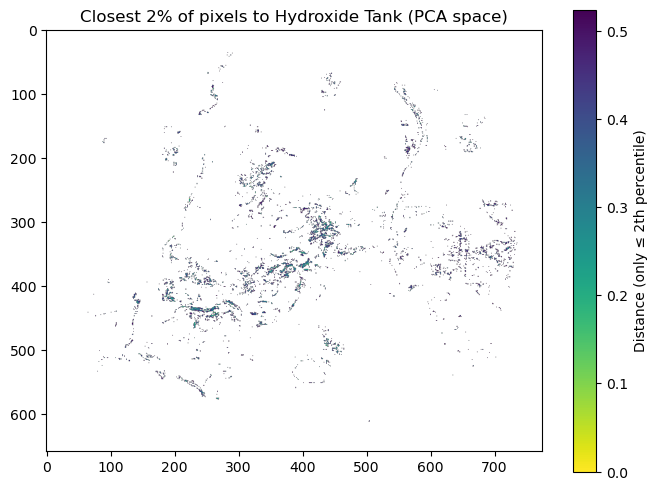

In [39]:
### calculate the distnces in PCA space from each pixel to the hydroxide tank, plot the distance map as an image
hydroxide_tank_pca = cobalt_tank_pca_values[-1,:]  # last tank is the hydroxide one

# calculate the euclidean distance from each pixel to the hydroxide tank in PCA space
distance_map = np.sqrt(np.sum((rad_pc_image - hydroxide_tank_pca[:, np.newaxis, np.newaxis])**2, axis=0))

# threshold before plotting to only show closest pixels
p = 2  # percentile of closest pixels to keep (try 1-5)
thresh = np.nanpercentile(distance_map, p)

mask = distance_map <= thresh
dist_masked = np.where(mask, distance_map, np.nan)   # set non-closest to NaN so they don't plot

plt.figure(figsize=(8,6))
plt.imshow(dist_masked, cmap='viridis_r')
plt.colorbar(label=f'Distance (only ≤ {p}th percentile)')
plt.title(f'Closest {p}% of pixels to Hydroxide Tank (PCA space)')
plt.show()

### Checkin

At this point, I'm not very hopeful that we'll be able to find other cobalt circuits or hydroxide tanks by just searching whole images for the most similar spectra to our one known example at KCC. That's okay though. Instead of digging deeper into this line and possibly wasting time, I'm gonna narrow down the search to just looking within processing facilities. It's pretty easy to make rough outlines of all the processing tanks in an image. So let's limit to that. We can start with the pca done on the whole image, or just the raw spectra, still doing the nearest neighbors search. If that doesn't turn up anything, we can also do a pca on just tank areas, or even just the KCC tanks, really trying to accentuate differences between cobalt decanters and the rest of them.

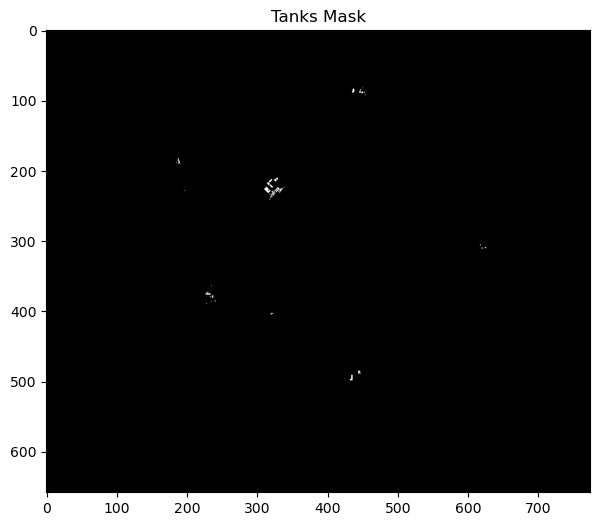

In [40]:
### load in the shapefile of all tanks at the facility, rasterize it to make a mask

# tanks shapefile subpath
tanks_shapefile_subpath = 'traced_polygons/tanks_areas/tanks_areas.shp'
tanks_shapefile_path = os.path.join(base_path, tanks_shapefile_subpath)

tanks_gdf = gpd.read_file(tanks_shapefile_path)

# check crs compared to the image and reproject if it doesn't match
if tanks_gdf.crs != ref_crs:
    tanks_gdf = tanks_gdf.to_crs(ref_crs)

# rasterize the tanks shapefile to make a mask
tanks_mask = rasterize(
    [(geom, 1) for geom in tanks_gdf.geometry],
    out_shape=ref_shape,
    transform=ref_transform,
    fill=0,
    dtype=np.uint8
)

# plot the tanks mask as a check
plt.figure(figsize=(8,6))
plt.imshow(tanks_mask, cmap='gray')
plt.title('Tanks Mask')
plt.show()


All tanks PCA values shape: (281, 5)
Cobalt tanks PCA values shape: (6, 5)


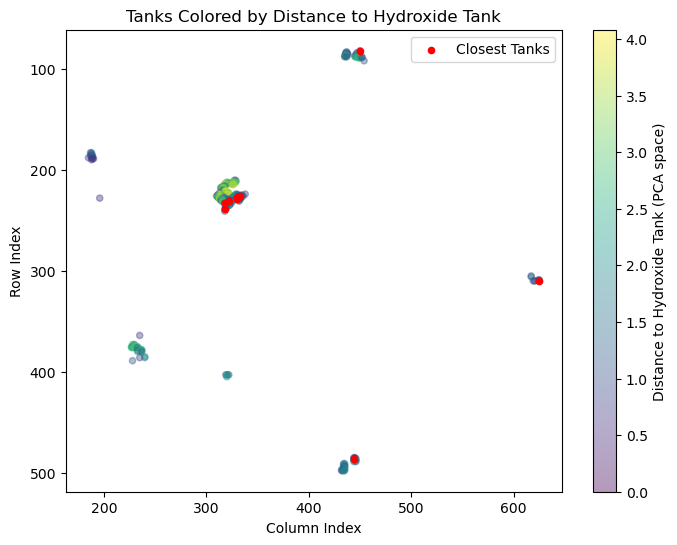

In [41]:
### extract the pca values at the tank locations, and plot some comparisons

# because we want to know where these pixels are in the image, we need to get their row, col indices, and extract the pca values that way
tank_indices = np.argwhere(tanks_mask == 1)
all_tanks_pca_values = rad_pc_image[:, tank_indices[:,0], tank_indices[:,1]].T

print("All tanks PCA values shape:", all_tanks_pca_values.shape)
print("Cobalt tanks PCA values shape:", cobalt_tank_pca_values.shape)

# do a distance comparison for all tanks to the hydroxide tank
tank_distances = np.sqrt(np.sum((all_tanks_pca_values - hydroxide_tank_pca[np.newaxis, :])**2, axis=1))

# get teh top 10 closest tanks
top_n = 10
closest_tank_indices = np.argsort(tank_distances)[:top_n]

# Now plot them at their pixel indices, color coded by distance to hydroxide tank
plt.figure(figsize=(8,6))
sc = plt.scatter(tank_indices[:,1], tank_indices[:,0], c=tank_distances, s=20, cmap='viridis',alpha=0.4)
# scatter the closest tanks in black with a larger size
plt.scatter(tank_indices[closest_tank_indices,1], tank_indices[closest_tank_indices,0], color='red', s=20, label='Closest Tanks')
plt.legend()
plt.colorbar(sc, label='Distance to Hydroxide Tank (PCA space)')
plt.title('Tanks Colored by Distance to Hydroxide Tank')
plt.xlabel('Column Index')
plt.ylabel('Row Index')
plt.gca().invert_yaxis()
plt.show()

### Checkin again

Okay, so some potentially interesting results there. The couple of tanks that show up at the metalkol and commus facilities are ones that I might have thought are to do with the cobalt circuit by eye. But nothing is definitive. One issues is that the cobalt circuit at KCC are all more similar to the hydroxide tank than pretty much all the other tanks in the area. I think what needs to happen next is a PCA that has just to do with tanks that will hopefully accentuate variance among tanks as opposed to the whole image.

In [42]:
### Run a pca on just the tank datset, and project the cobalt circuit from KCC into that space

tank_radiance_values = rad_array_masked[:, tank_indices[:,0], tank_indices[:,1]].T

# run the pca
n_components_tank = 5
pca_tank = PCA(n_components=n_components_tank)
pca_tank.fit(tank_radiance_values)
all_tank_pc_vals_tank_space = tank_radiance_values @ pca_tank.components_.T

# grab the component spectra for projecting
tank_component_spectra = pca_tank.components_

# project the cobalt tank spectra from KCC into this tank pca space
cobalt_tank_radiance_values = rad_array_masked[:, [row for (row, col) in cobalt_tank_pixels], [col for (row, col) in cobalt_tank_pixels]].T 
cobalt_tank_pca_tank_space = cobalt_tank_radiance_values @ tank_component_spectra.T
print("All tanks PCA (tank space) shape:", all_tank_pc_vals_tank_space.shape)
print("Cobalt tank PCA (tank space) shape:", cobalt_tank_pca_tank_space.shape)



All tanks PCA (tank space) shape: (281, 5)
Cobalt tank PCA (tank space) shape: (6, 5)


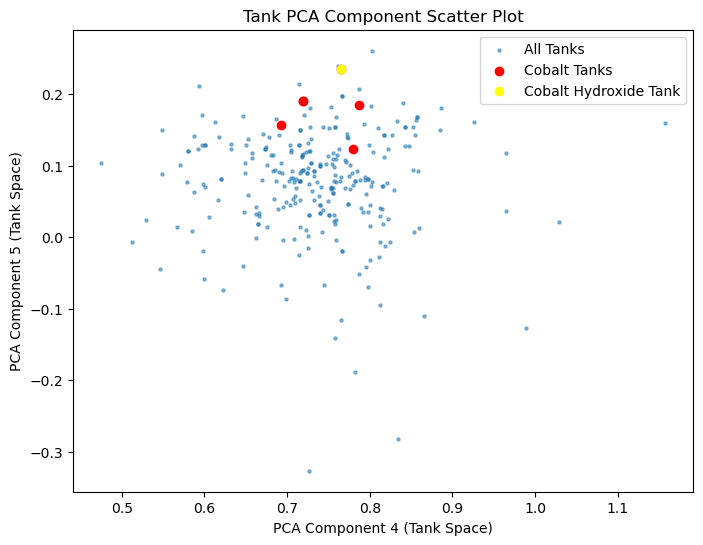

In [43]:
### cross plot to see how things look for now

px_x = 3
pc_y = 4
plt.figure(figsize=(8, 6))
plt.scatter(all_tank_pc_vals_tank_space[:, px_x], all_tank_pc_vals_tank_space[:, pc_y], s=5, alpha=0.5, label='All Tanks')
plt.scatter(cobalt_tank_pca_tank_space[:, px_x], cobalt_tank_pca_tank_space[:, pc_y], color='red', label='Cobalt Tanks')
# also scatter the last tank in another color, as that is the one with cobalt hydroxide
plt.scatter(cobalt_tank_pca_tank_space[-1, px_x], cobalt_tank_pca_tank_space[-1, pc_y], color='yellow', label='Cobalt Hydroxide Tank')
plt.xlabel(f'PCA Component {px_x+1} (Tank Space)')
plt.ylabel(f'PCA Component {pc_y+1} (Tank Space)')
plt.title('Tank PCA Component Scatter Plot')
plt.legend()
plt.show()

In [44]:
### to make these results a little easier to see, we'll get some knowledge of which processing facility is which

# gotta load in the facility shapefile
facilities_shapefile_subpath = 'traced_polygons/processing_facilities/processing_facilities.shp'
facilities_shapefile_path = os.path.join(base_path, facilities_shapefile_subpath)

facilities_gdf = gpd.read_file(facilities_shapefile_path)

# check crs and reproject if needed
if facilities_gdf.crs != ref_crs:
    facilities_gdf = facilities_gdf.to_crs(ref_crs)

#for each facility, get the bounding boxes 
facility_bboxes = []
for geom in facilities_gdf.geometry:
    minx, miny, maxx, maxy = geom.bounds
    # and convert into pixel coordinates
    minrow, mincol = rio.transform.rowcol(ref_transform, minx, maxy)  # upper left
    maxrow, maxcol = rio.transform.rowcol(ref_transform, maxx, miny)  # lower right
    # create a box in pixel coordinates
    facility_bboxes.append(box(mincol, minrow, maxcol, maxrow))
    print("Facility bounding box (col,row):", (mincol, minrow, maxcol, maxrow))

# print the number of facilities found, so the user knows how many subplots to expect in the next cell
print("Number of processing facilities found:", len(facility_bboxes))

Facility bounding box (col,row): (np.int32(308), np.int32(209), np.int32(340), np.int32(243))
Facility bounding box (col,row): (np.int32(609), np.int32(303), np.int32(629), np.int32(315))
Facility bounding box (col,row): (np.int32(429), np.int32(474), np.int32(450), np.int32(499))
Facility bounding box (col,row): (np.int32(224), np.int32(358), np.int32(273), np.int32(400))
Facility bounding box (col,row): (np.int32(310), np.int32(402), np.int32(324), np.int32(407))
Facility bounding box (col,row): (np.int32(183), np.int32(167), np.int32(216), np.int32(206))
Facility bounding box (col,row): (np.int32(193), np.int32(220), np.int32(203), np.int32(232))
Facility bounding box (col,row): (np.int32(423), np.int32(63), np.int32(465), np.int32(106))
Number of processing facilities found: 8


Plotting facility bbox on overall map: (308, 209, 340, 243)
Plotting facility bbox on overall map: (609, 303, 629, 315)
Plotting facility bbox on overall map: (429, 474, 450, 499)
Plotting facility bbox on overall map: (224, 358, 273, 400)
Plotting facility bbox on overall map: (310, 402, 324, 407)
Plotting facility bbox on overall map: (183, 167, 216, 206)
Plotting facility bbox on overall map: (193, 220, 203, 232)
Plotting facility bbox on overall map: (423, 63, 465, 106)


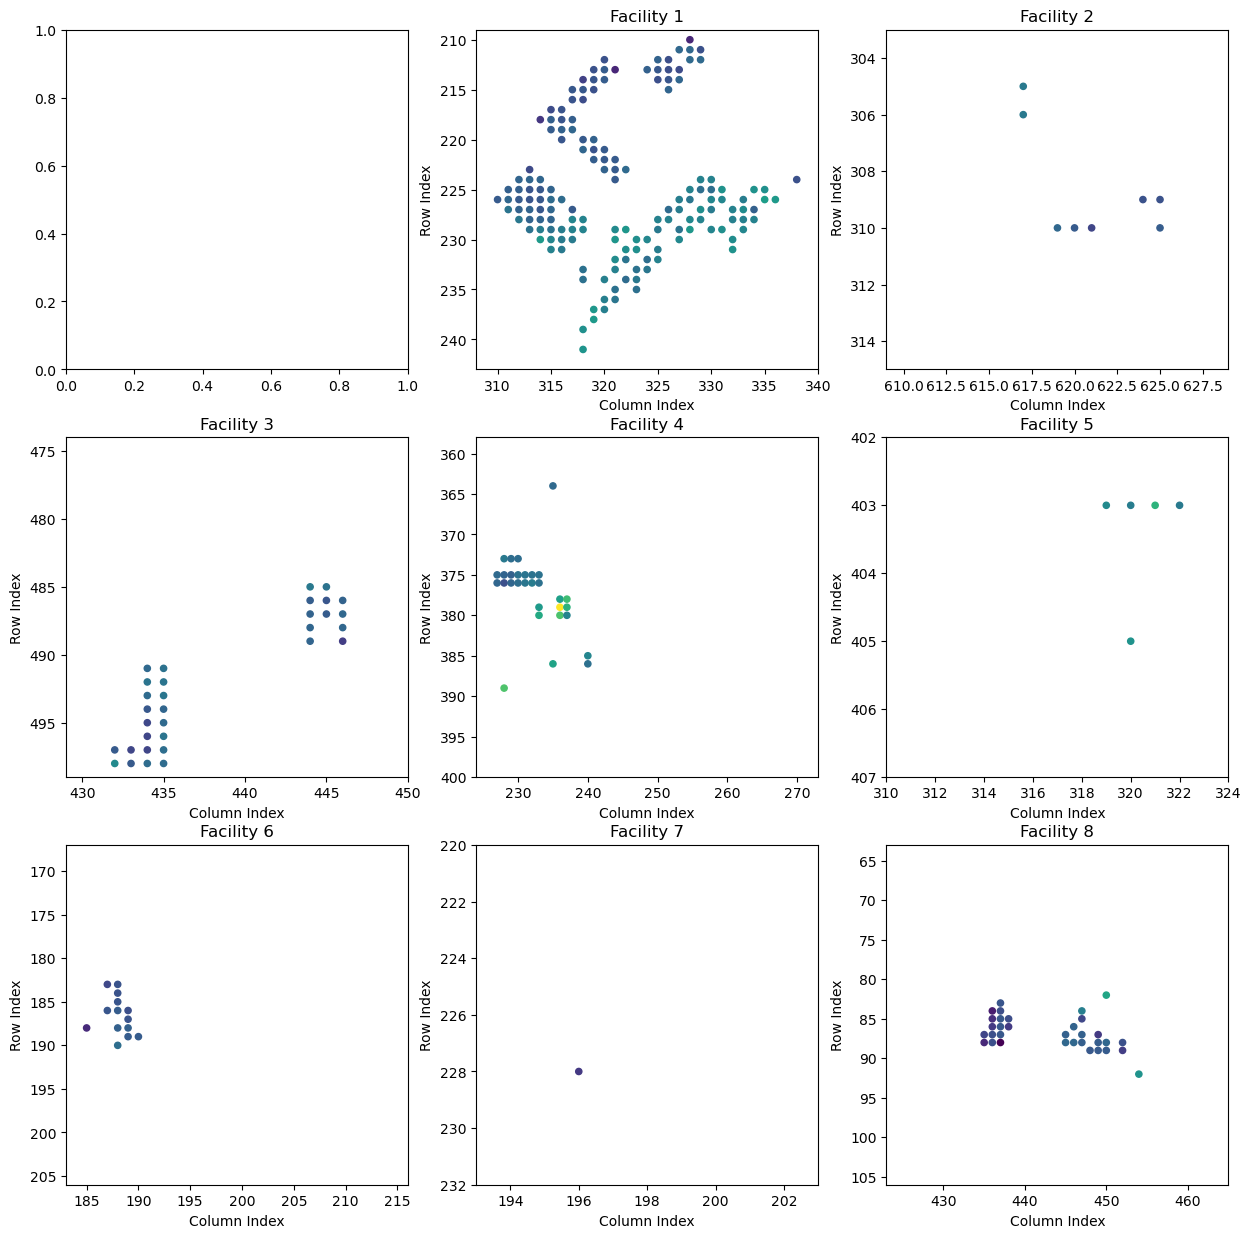

In [48]:
### now we can plot each facility's tanks separately to see if anything stands out, upper left will be a general map

pc_plot = 1

# set up the subplot grid, we know there are 8 facilities, plus the overall map
fig, axs = plt.subplots(3, 3, figsize=(15, 15))
axs = axs.flatten()

# plot the overall map in the upper left
count = 0
for bbox in facility_bboxes:
    mincol, minrow, maxcol, maxrow = map(int, bbox.bounds)
    print("Plotting facility bbox on overall map:", (mincol, minrow, maxcol, maxrow))
    rect = plt.Rectangle((mincol, minrow), maxcol - mincol, maxrow - minrow,
                         linewidth=2, edgecolor='red', facecolor='none')
    axs[0].add_patch(rect)

    # and put a label at the center
    #center_x = (mincol + maxcol) / 2
    #center_y = (minrow + maxrow) / 2
    #axs[0, 0].text(center_x, center_y, 'Facility', color='red', fontsize=12, ha='center', va='center')

    # plot all tanks in the right axes, color coded by pc, using the bbox to limit
    axs[count + 1].set_title(f'Facility {count + 1}')
    axs[count + 1].scatter(tank_indices[:,1], tank_indices[:,0], c=all_tank_pc_vals_tank_space[:, pc_plot], s=20, cmap='viridis')
    # limit to the bbox
    axs[count + 1].set_xlim(mincol, maxcol)
    axs[count + 1].set_ylim(maxrow, minrow)  # invert y
    axs[count + 1].invert_yaxis()
    axs[count + 1].set_xlabel('Column Index')
    axs[count + 1].set_ylabel('Row Index')
    # invert the y axis
    axs[count + 1].invert_yaxis()

    count += 1


plt.show()

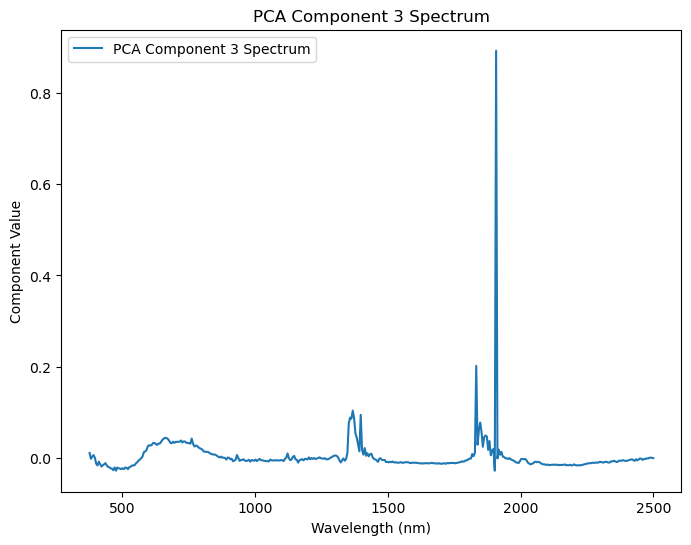

In [52]:
### make a plot of any pc spctrum

pc_to_plot = 2  # change this to plot different pcs

plt.figure(figsize=(8,6))
plt.plot(rad_attrs['wavelengths'], tank_component_spectra[pc_to_plot], label=f'PCA Component {pc_to_plot+1} Spectrum')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Component Value')
plt.title(f'PCA Component {pc_to_plot+1} Spectrum')
plt.legend()
plt.show()


Highest scoring pixel in PC4 at Facility 8:
Pixel indices (row, col): [ 92 454]
PCA values: [ 4.0935388   1.7449877   0.9913743   0.5124974  -0.00708059]


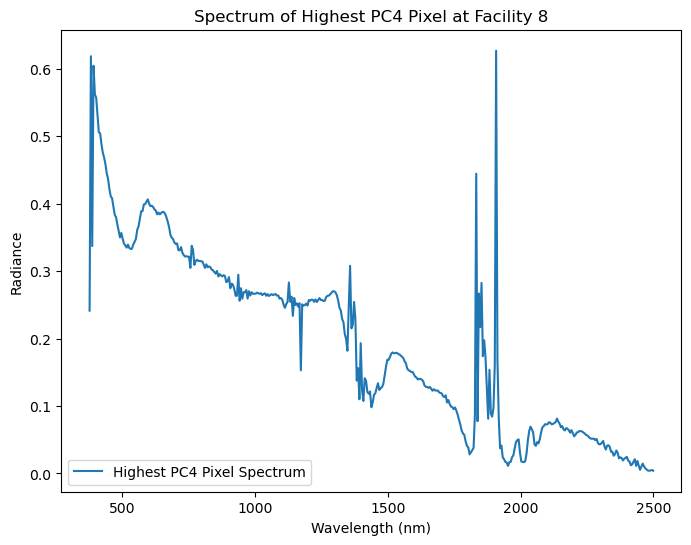

In [53]:
### get the highest scoring pixel in pc4 at facility 8

# get the pixel indidces for facility 8
facility_8_bbox = facility_bboxes[7]  # zero indexed
mincol, minrow, maxcol, maxrow = map(int, facility_8_bbox.bounds)

# pixel ind mask
pixel_inds_mask = (tank_indices[:,0] >= minrow) & (tank_indices[:,0] <= maxrow) & \
                  (tank_indices[:,1] >= mincol) & (tank_indices[:,1] <= maxcol)

facility_8_tank_indices = tank_indices[pixel_inds_mask]
facility_8_tank_pca_values = all_tank_pc_vals_tank_space[pixel_inds_mask]

# get the index of the highest scoring pixel in pc4
highest_pc4_index = np.argmax(facility_8_tank_pca_values[:, pc_to_plot])
print("Highest scoring pixel in PC4 at Facility 8:")
print("Pixel indices (row, col):", facility_8_tank_indices[highest_pc4_index])
print("PCA values:", facility_8_tank_pca_values[highest_pc4_index])

# and plot its spectrum
highest_pc4_pixel = facility_8_tank_indices[highest_pc4_index]
spectrum = rad_array_masked[:, highest_pc4_pixel[0], highest_pc4_pixel[1]]
plt.figure(figsize=(8,6))
plt.plot(rad_attrs['wavelengths'], spectrum, label='Highest PC4 Pixel Spectrum')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Radiance')
plt.title('Spectrum of Highest PC4 Pixel at Facility 8')
plt.legend()
plt.show()

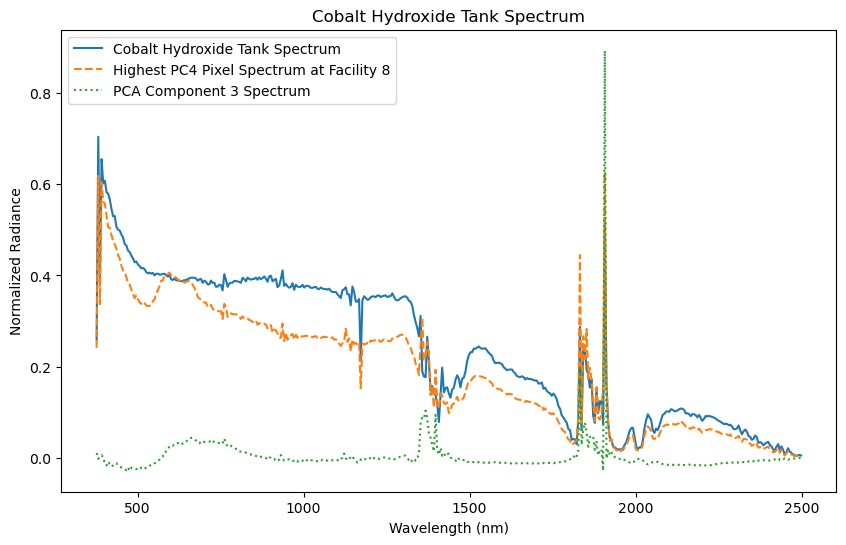

In [54]:
### plot the raw spectrum of the copbalt hydroxide tank

hydroxide_tank_pixel = cobalt_tank_pixels[-1]
hydroxide_tank_spectrum = rad_array_masked[:, hydroxide_tank_pixel[0], hydroxide_tank_pixel[1]] 
plt.figure(figsize=(10,6))
plt.plot(rad_attrs['wavelengths'], hydroxide_tank_spectrum, label='Cobalt Hydroxide Tank Spectrum')
# with the pixel from the previous cell for comparison
plt.plot(rad_attrs['wavelengths'], spectrum, label='Highest PC4 Pixel Spectrum at Facility 8', linestyle='--')
# and pc 4 component spectrum for reference
plt.plot(rad_attrs['wavelengths'], tank_component_spectra[pc_to_plot], label=f'PCA Component {pc_to_plot+1} Spectrum', linestyle=':')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Normalized Radiance')
plt.title('Cobalt Hydroxide Tank Spectrum')
plt.legend()
plt.show()

In [32]:
### print the variance explained by each tank pca component
print("Tank PCA Explained variance ratio:", pca_tank.explained_variance_ratio_)


Tank PCA Explained variance ratio: [0.9503055  0.03688543 0.00564641 0.00409059 0.0010183 ]


### Next steps

1. K-S test on spectra compared to known cobalt tanks
    * Is it a tank? 
    * Then is it a tank that contains cobalt?

(Try without masking bands)